<a href="https://colab.research.google.com/github/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [ ]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [ ]:
N_BOOTSTRAP = 10_000
n           = len(driver_tips)
boot_medians = np.empty(N_BOOTSTRAP)

for i in range(N_BOOTSTRAP):
  resample = driver_tips[np.random.randint(0, n, size=n)]
  boot_medians[i] = np.median(resample)

# for conf interval
ci_lower = np.percentile(boot_medians, 2.5)
ci_upper = np.percentile(boot_medians, 97.5)
observed_median = np.median(driver_tips)

print(f"\nBootstrap Results (n_iterations = {N_BOOTSTRAP:,}):")
print(f"Observed Median : ${observed_median:.4f}")
print(f"95% CI Lower    : ${ci_lower:.4f}")
print(f"95% CI Upper    : ${ci_upper:.4f}")
print(f"Lower distance  : ${observed_median - ci_lower:.4f}")
print(f"Upper distance  : ${ci_upper - observed_median:.4f}")


Bootstrap Results (n_iterations = 10,000):
Observed Median : $0.7553
95% CI Lower    : $0.2817
95% CI Upper    : $1.2990
Lower distance  : $0.4736
Upper distance  : $0.5437


It's asymmetric because the tip distribution is zero-inflated and right-skewed so the bootstrap medians don't form a symmetric bell curve. The upper tail stretches further than the lower tail (the median can be pulled up by outliers but is floored near $0 by the zero-mass). A standard parametric CI assumes symmetry around the point estimate, which would be wrong here. The bootstrapped percentile CI captures the actual shape of the sampling distribution empirically, making it far more honest for this kind of data. So basically the bootstrapped data medians shows the truth, which is skewed since the data was skewed from the beginning.

In [ ]:
control = np.random.normal(loc=35, scale=10, size=500)
treatment = np.random.lognormal(mean=(3.5), sigma=(0.4), size=500)

#observed diff
observed_diff = np.mean(control) - np.mean(treatment)

print(f"Control mean: {np.mean(control):.4f} min")
print(f"Treatment mean: {np.mean(treatment):.4f} min")
print(f"Observed diff: {observed_diff:.4f} min")

Control mean: 34.8848 min
Treatment mean: 36.3052 min
Observed diff: -1.4204 min


In [ ]:
N_PERMUTATIONS = 5_000

combined = np.concatenate([control, treatment])

perm_diffs = np.empty(N_PERMUTATIONS)

for i in range(N_PERMUTATIONS):
    shuffled = np.random.permutation(combined)

    fake_control   = shuffled[:500]
    fake_treatment = shuffled[500:]

    perm_diffs[i] = np.mean(fake_control) - np.mean(fake_treatment)

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"Observed Difference : {observed_diff:.5f} min")
print(f"Empirical P-value   : {p_value:.5f}")

print(f"p_value: {p_value:.4f} is not less than 0.05 → Result: NOT significant. Difference could be due to random chance.")

Observed Difference : -1.42040 min
Empirical P-value   : 0.08540
p_value: 0.0854 is not less than 0.05 → Result: NOT significant. Difference could be due to random chance.


In [ ]:
uploaded = files.upload()

df = pd.read_csv('swiftcart_loyalty.csv')

Saving swiftcart_loyalty.csv to swiftcart_loyalty (1).csv


In [ ]:
# Calculate the Naive Simple Difference in Means (SDO) for post-treatment spending explicitly comparing Subscribers (D=1) and Non-Subscribers (D=0
df = pd.read_csv('swiftcart_loyalty.csv')

subscribers = df[df['subscriber'] == 1]
non_subscribers = df[df['subscriber'] == 0]

mean_sub     = subscribers['post_spend'].mean()
mean_non_sub = non_subscribers['post_spend'].mean()
naive_sdo    = mean_sub - mean_non_sub

print(f"Subscriber mean spending     : ${mean_sub:.2f}")
print(f"Non-Subscriber mean spending : ${mean_non_sub:.2f}")
print(f"Naive SDO (D=1 minus D=0)    : ${naive_sdo:.2f}")

Subscriber mean spending     : $74.04
Non-Subscriber mean spending : $56.47
Naive SDO (D=1 minus D=0)    : $17.57


In [ ]:
covariates = ['pre_spend', 'account_age', 'support_tickets']

X = df[covariates]
y = df['subscriber']

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

lr = LogisticRegression(random_state=42)
lr.fit(X_scaled, y)

df['propensity_score'] = lr.predict_proba(X_scaled)[:, 1]

treated_ps  = df[df['subscriber'] == 1][['propensity_score']]
control_ps  = df[df['subscriber'] == 0][['propensity_score']]

nn = NearestNeighbors(n_neighbors=1)  # n_neighbors=1 means ONE closest match
nn.fit(control_ps)
distances, indices = nn.kneighbors(treated_ps)
matched_control = df[df['subscriber'] == 0].iloc[indices.flatten()].copy()

att = df[df['subscriber'] == 1]['post_spend'].mean() - matched_control['post_spend'].mean()


print(f"Treated mean spending: ${df[df['subscriber']==1]['post_spend'].mean():.2f}")
print(f"Matched control mean spending: ${matched_control['post_spend'].mean():.2f}")
print(f"ATT (causal estimate): ${att:.2f}")

print(f"\n── Comparison ──")
print(f"Naive SDO : ${naive_sdo:.2f}  ← inflated by selection bias")
print(f"Causal ATT: ${att:.2f}  ← isolates true program effect")
print(f"Bias: ${naive_sdo - att:.2f} absorbed by self-selection")

Treated mean spending: $74.04
Matched control mean spending: $64.02
ATT (causal estimate): $10.02

── Comparison ──
Naive SDO : $17.57  ← inflated by selection bias
Causal ATT: $10.02  ← isolates true program effect
Bias: $7.55 absorbed by self-selection


The Naive SDO of \$17.57 is what the marketing team is basing their budget request on, but this number is misleading. It only reflects the fact that people who subscribed to SwiftPass were already heavy spenders before the program existed. They self-selected in because they order frequently and wanted to save on cumulative fees, not because SwiftPass transformed their behavior.

After applying Propensity Score Matching, the true causal ATT is only \$10.02 which was calculated by pairing each subscriber with the non-subscriber most similar to them in pre-treatment behavior, meaning the comparison is now apples-to-apples. The \$10.02 difference is what SwiftPass actually caused.

The gap between the two --> \$7.55 is pure selection bias. It was never a program effect, but was a description of who power users already were before SwiftPass existed.

So, the marketing team's claim that SwiftPass drives \$17.57 in additional spending is overstated by nearly 43% ((17.57 - 10.02) / 17.57). The true incremental value of acquiring a new SwiftPass subscriber is closer to \$10.02, and the budget request should be scaled accordingly.






── Standardized Mean Differences ──
      Covariate  Before PSM  After PSM
      pre_spend    0.673959   0.009438
    account_age    0.324109   0.004861
support_tickets    0.166146   0.022800


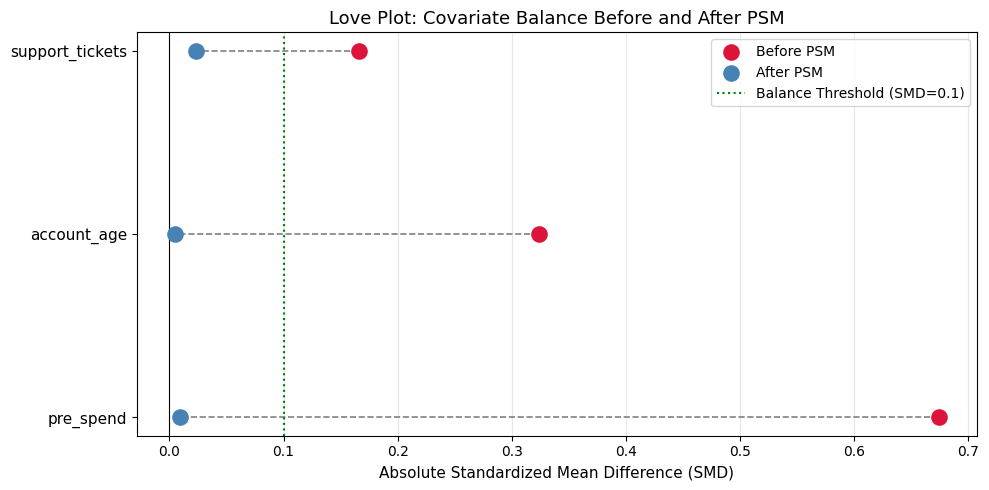

In [ ]:
# AI Love Plot
# ── Phase 4.1: Love Plot – Covariate Balance Before & After PSM ───────────────

# Build df_unmatched and df_matched from your existing data
covariates = ['pre_spend', 'account_age', 'support_tickets']

treated     = df[df['subscriber'] == 1]
df_unmatched = pd.concat([treated, df[df['subscriber'] == 0]], ignore_index=True)
df_matched   = pd.concat([treated, matched_control],  ignore_index=True)

# ── Standardized Mean Difference (SMD) Calculator ────────────────────────────
def compute_smd(data, covariates, treatment_col='subscriber'):
    smds = {}
    treated_group  = data[data[treatment_col] == 1]
    control_group  = data[data[treatment_col] == 0]
    for col in covariates:
        mean_t  = treated_group[col].mean()
        mean_c  = control_group[col].mean()
        # Pooled standard deviation
        pooled_std = np.sqrt((treated_group[col].var() + control_group[col].var()) / 2)
        smds[col] = abs((mean_t - mean_c) / pooled_std)
    return smds

smd_before = compute_smd(df_unmatched, covariates)
smd_after  = compute_smd(df_matched,   covariates)

# ── Build Summary DataFrame ───────────────────────────────────────────────────
balance_df = pd.DataFrame({
    'Covariate'  : covariates,
    'Before PSM' : [smd_before[c] for c in covariates],
    'After PSM'  : [smd_after[c]  for c in covariates]
})

print("── Standardized Mean Differences ──")
print(balance_df.to_string(index=False))

# ── Love Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

y_pos = range(len(covariates))

ax.scatter(balance_df['Before PSM'], y_pos,
           color='crimson', s=120, zorder=3, label='Before PSM')
ax.scatter(balance_df['After PSM'],  y_pos,
           color='steelblue', s=120, zorder=3, label='After PSM')

# Draw lines connecting before/after for each covariate
for i, covariate in enumerate(covariates):
    ax.plot([balance_df['Before PSM'][i], balance_df['After PSM'][i]],
            [i, i], color='gray', lw=1.2, linestyle='--', zorder=2)

# Reference lines
ax.axvline(x=0.1, color='green', linestyle=':', lw=1.5, label='Balance Threshold (SMD=0.1)')
ax.axvline(x=0.0, color='black', linestyle='-',  lw=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(balance_df['Covariate'], fontsize=11)
ax.set_xlabel('Absolute Standardized Mean Difference (SMD)', fontsize=11)
ax.set_title('Love Plot: Covariate Balance Before and After PSM', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()